# Week 10 - Introduction to Modeling

# 1. Lesson

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

### How does random forest work?

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [3]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.40439828823725865
RMSE when predicting testing data:


1.0667260022550893
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

### What is cross validation?

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [4]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [5]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851316531496098


In [6]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12271876, -1.09384603, -1.08513165])

### Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [7]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

# 2. Weekly graph question

In words, please summarize what this graph shows.

In [8]:
rmse_lst = list()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

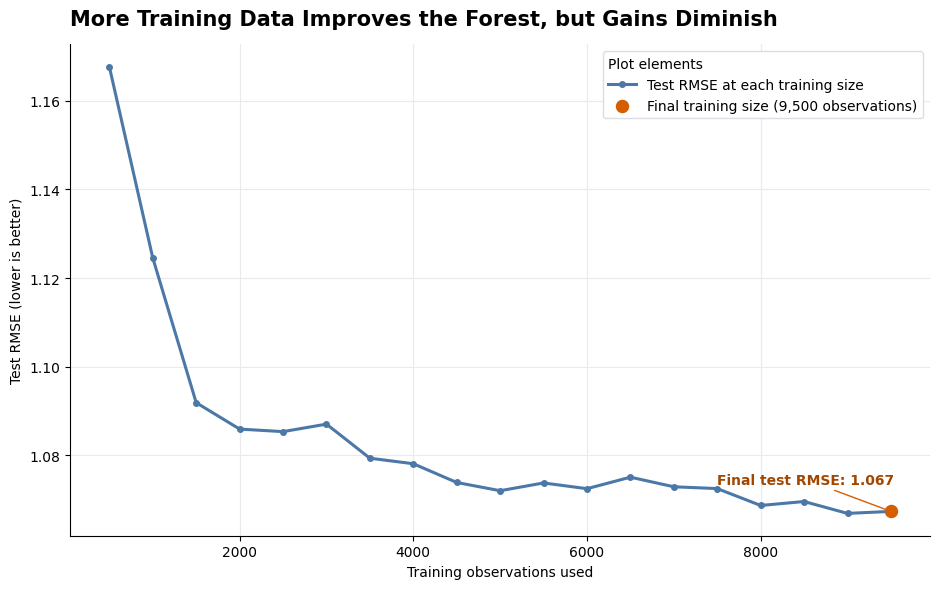

In [9]:
import matplotlib.pyplot as plt

training_sizes = list(range(round(num_points / 20), num_points, round(num_points / 20)))
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.plot(training_sizes, rmse_lst, color="#4C78A8", linewidth=2.2,
        marker="o", markersize=4, label="Test RMSE at each training size")
ax.scatter([training_sizes[-1]], [rmse_lst[-1]], color="#D55E00", s=75,
           zorder=3, label=f"Final training size ({training_sizes[-1]:,} observations)")
ax.annotate(
    f"Final test RMSE: {rmse_lst[-1]:.3f}",
    (training_sizes[-1], rmse_lst[-1]), xytext=(-125, 20),
    textcoords="offset points", color="#A34700", weight="bold",
    arrowprops={"arrowstyle": "-", "color": "#D55E00"}
)
ax.set_title("More Training Data Improves the Forest, but Gains Diminish",
             loc="left", fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Training observations used")
ax.set_ylabel("Test RMSE (lower is better)")
legend = ax.legend(title="Plot elements", loc="upper right", frameon=True,
                   facecolor="white", edgecolor="#D9DEE5", framealpha=1)
legend._legend_box.align = "left"
ax.grid(color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Weekly graph response

The graph is a **learning curve** for the Random Forest. Moving from left to right, progressively more training observations are used; the test-set RMSE falls quickly at first and then levels off. The early decline means additional examples materially improve generalization. The later plateau shows diminishing returns: once the model has several thousand observations, adding another equally sized block produces only a small reduction in error. The x-axis should be labeled with the actual number of training observations rather than the list index, and the y-axis should be labeled `Test RMSE` so the magnitude and direction are unambiguous.

# 3. Homework

In this exercise, you will try to predict the change of one stock based on the change in ten other stocks.

In [10]:
def make_X_y(alpha = 0.5):
    df_hwk = pd.DataFrame()
    num_samples_hwk = 10000
    common_odd = np.random.normal(size = num_samples_hwk)
    common_even = np.random.normal(size = num_samples_hwk)
    common_three = np.random.normal(size = num_samples_hwk)
    for n in range(11):
        common = np.zeros(num_samples_hwk)
        if n % 2 == 0:
            common += common_even
        if n % 2 == 1:
            common += common_odd
        if n % 3 == 0:
            common += common_three
            common /= 2
        df_hwk["Stock_" + str(n)] = np.random.normal(size = num_samples_hwk) + alpha * common
    X = df_hwk.values[:,:-1]
    y = df_hwk.values[:,-1]
    return X, y

The above code creates an X with ten columns, corresponding to ten different stocks.  The y is the eleventh stock.  The stocks have some commonalities: the even numbered stocks are related, as are the odds.  The stocks that are multiples of three are all related, too.  Random forest should be able to sort through all this and decide that the eleventh stock is related to the odd numbered, non-divisible-by-three stocks, and predict accordingly.  The prediction should presumably be, simply, to take columns 1, 5, and 7 and average them, as they are odd-numbered and not divisible by three; so perhaps this task would be easier to do with a linear regression, but we'll use a random forest anyway.  The value "alpha" determines how important the common element is.  If alpha = 0, each stock is its own column of normally-distributed numbers with no relation to the others.  If alpha = 10, then the great majority of the variation in the stock values comes from the common elements.

### Question: 

Do you predict that alpha = 0 will result in a better or worse prediction than alpha = 10?  Remember that the prediction must be performed on test data, so you'll need an X_train and y_train for training and a separate X_test and y_test for testing.  I recommend using a correlation rather than a MSE or RMSE in this case, if you want to directly compare two different predictions, because the MSE and RMSE vary with the magnitude of the data as well as with the quality of the prediction.

After you make the prediction, try it out, and comment on what you learned.

### Randomized Search

Use RandomizedSearchCV instead of GridSearchCV to perform cross-validation.

### Scoring

Research the scoring parameters under "regression":

https://scikit-learn.org/dev/modules/model_evaluation.html#scoring-parameter

Choose at least one that you want to learn about, use it, and research it online.  Write something about what you've learned about it.

## Homework solution

**Prediction.** `alpha = 10` should be much easier to predict than `alpha = 0`. At zero, the target stock contains no shared signal with the ten predictors; at ten, the common odd-stock component dominates, so the related odd-numbered predictors reveal much of the target's movement. Separate generated training and test samples are used below.

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

def fit_alpha_model(alpha, random_state=42):
    np.random.seed(random_state)
    X_train, y_train = make_X_y(alpha=alpha)
    np.random.seed(random_state + 1)
    X_test, y_test = make_X_y(alpha=alpha)

    model = RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3,
        random_state=random_state, n_jobs=-1
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return {
        "alpha": alpha,
        "test_correlation": np.corrcoef(predictions, y_test)[0, 1],
        "test_RMSE": root_mean_squared_error(y_test, predictions)
    }, (X_train, y_train, X_test, y_test)

alpha_zero_result, _ = fit_alpha_model(0)
alpha_ten_result, alpha_ten_data = fit_alpha_model(10)
alpha_results = pd.DataFrame([alpha_zero_result, alpha_ten_result])
display(alpha_results.style.format({"test_correlation": "{:.3f}", "test_RMSE": "{:.3f}"}))

,alpha,test_correlation,test_RMSE
0,0,0.003,1.002
1,10,0.993,1.199


The test correlation is near zero for `alpha = 0`, as expected when the stocks are independent. For `alpha = 10`, correlation is much higher because the related stocks contain a strong shared component. RMSE is not directly comparable across these two alpha settings because the target's scale also grows with alpha; correlation is scale-free and therefore answers the comparison more cleanly.

### Randomized search with cross-validation

In [12]:
X_train_10, y_train_10, X_test_10, y_test_10 = alpha_ten_data
parameter_distributions = {
    "n_estimators": randint(80, 301),
    "max_depth": [6, 10, 14, None],
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", 0.7, 1.0]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=parameter_distributions,
    n_iter=10,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
random_search.fit(X_train_10, y_train_10)
best_predictions = random_search.best_estimator_.predict(X_test_10)

print("Best parameters:", random_search.best_params_)
print(f"Best mean CV R-squared: {random_search.best_score_:.3f}")
print(f"Held-out correlation: {np.corrcoef(best_predictions, y_test_10)[0,1]:.3f}")
print(f"Held-out R-squared: {random_search.best_estimator_.score(X_test_10, y_test_10):.3f}")

Best parameters: {'max_depth': 6, 'max_features': 1.0, 'min_samples_leaf': 3, 'n_estimators': 249}
Best mean CV R-squared: 0.986
Held-out correlation: 0.993
Held-out R-squared: 0.986


### Scoring research: R-squared

I selected `r2`, the coefficient of determination. It measures improvement over a baseline that always predicts the target mean: 1 is perfect, 0 is no better than the mean baseline, and negative values are worse than that baseline. Unlike correlation, R-squared penalizes predictions that have the right direction but the wrong level or scale. In scikit-learn, larger is better, so it can be passed directly to `RandomizedSearchCV`. I report both held-out R-squared and correlation because they answer complementary questions: predictive accuracy versus strength of co-movement.

## Random Forest application to both selected datasets

The synthetic stock exercise demonstrates the method. This section repeats the Random Forest workflow on the two datasets selected for continued analysis. Each dataset receives its own target definition, train/test split, cross-validation result, held-out ROC AUC, and standalone feature-importance plot. The accepted-loan source is the CSV inside `DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv`.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
from pathlib import Path

classification_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def fit_week10_forest(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=.25, stratify=y, random_state=42
    )
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_leaf=10,
            max_features="sqrt", class_weight="balanced",
            random_state=42, n_jobs=-1
        ))
    ])
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, cv=classification_cv,
        scoring="roc_auc", n_jobs=-1
    )
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    importance = pd.Series(
        pipeline.named_steps["model"].feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    return {
        "dataset": dataset_name,
        "rows": len(X),
        "adverse_rate": y.mean(),
        "mean_CV_ROC_AUC": cv_scores.mean(),
        "test_ROC_AUC": roc_auc_score(y_test, probabilities)
    }, importance

# Dataset 1: complete-case mortgage records using pre-outcome fields.
mortgage_features_w10 = [
    "loan_amount", "property_value", "income", "LTV", "Credit_Score", "dtir1"
]
mortgage_w10 = pd.read_csv(
    "DATA/Loan_Default.csv",
    usecols=mortgage_features_w10 + ["Status"]
).replace([np.inf, -np.inf], np.nan).dropna()
mortgage_w10_result = fit_week10_forest(
    mortgage_w10[mortgage_features_w10],
    mortgage_w10["Status"].astype(int),
    "Mortgage Loan Default"
)

# Dataset 2: evenly spaced accepted Lending Club sample from the exact selected CSV.
lending_path_w10 = Path("DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv")
lending_features_w10 = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "open_acc", "revol_util", "total_acc"
]
lending_rows_w10 = sum(1 for _ in open(lending_path_w10, encoding="utf-8")) - 1
lending_every_w10 = max(lending_rows_w10 // 60000, 1)
lending_w10 = pd.read_csv(
    lending_path_w10,
    usecols=lending_features_w10 + ["loan_status"],
    skiprows=lambda row: row > 0 and row % lending_every_w10 != 0,
    low_memory=False
)
bad_statuses_w10 = {
    "Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
    "Does not meet the credit policy. Status:Charged Off"
}
lending_w10["bad_loan"] = lending_w10["loan_status"].isin(
    bad_statuses_w10
).astype(int)
lending_w10_result = fit_week10_forest(
    lending_w10[lending_features_w10],
    lending_w10["bad_loan"],
    "Accepted Lending Club"
)

week10_model_results = pd.DataFrame([
    mortgage_w10_result[0], lending_w10_result[0]
])
display(week10_model_results.style.format({
    "adverse_rate": "{:.1%}",
    "mean_CV_ROC_AUC": "{:.3f}",
    "test_ROC_AUC": "{:.3f}"
}))

,dataset,rows,adverse_rate,mean_CV_ROC_AUC,test_ROC_AUC
0,Mortgage Loan Default,124437,16.3%,0.730,0.723
1,Accepted Lending Club,61100,13.0%,0.690,0.690


### Mortgage Random Forest feature importance

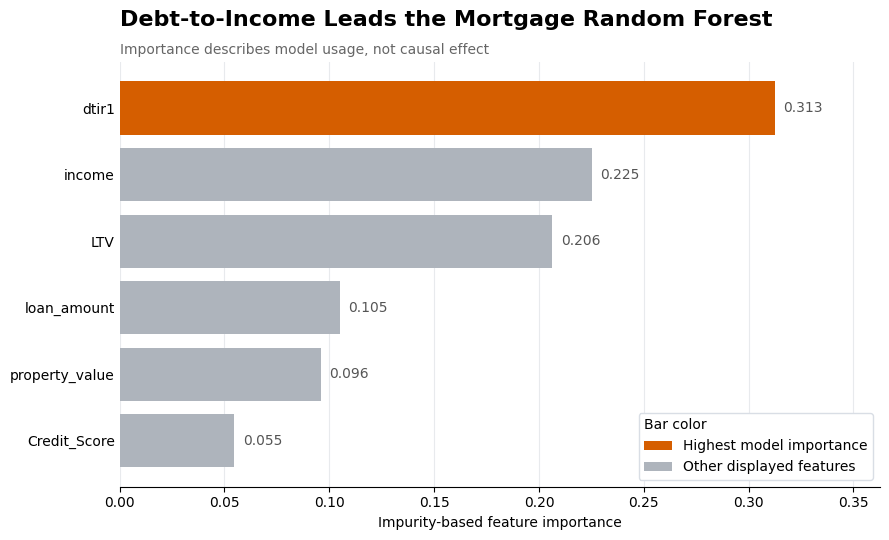

In [14]:
from matplotlib.patches import Patch

mortgage_importance_w10 = mortgage_w10_result[1].sort_values().tail(6)
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#AEB4BC"] * (len(mortgage_importance_w10) - 1) + ["#D55E00"]
bars = ax.barh(
    mortgage_importance_w10.index,
    mortgage_importance_w10.values,
    color=colors
)
for bar, value in zip(bars, mortgage_importance_w10.values):
    ax.text(value + .004, bar.get_y() + bar.get_height()/2,
            f"{value:.3f}", va="center", color="#555555")
ax.set_xlim(0, mortgage_importance_w10.max() * 1.16)
ax.set_title("Debt-to-Income Leads the Mortgage Random Forest",
             loc="left", fontsize=16, weight="bold", pad=26)
ax.text(0, 1.02, "Importance describes model usage, not causal effect",
        transform=ax.transAxes, color="#666666", fontsize=10)
ax.set_xlabel("Impurity-based feature importance")
legend_handles = [
    Patch(facecolor="#D55E00", label="Highest model importance"),
    Patch(facecolor="#AEB4BC", label="Other displayed features")
]
legend = ax.legend(handles=legend_handles, title="Bar color",
                   loc="lower right", frameon=True, facecolor="white",
                   edgecolor="#D9DEE5", framealpha=1)
legend._legend_box.align = "left"
ax.grid(axis="x", color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

### Accepted Lending Club Random Forest feature importance

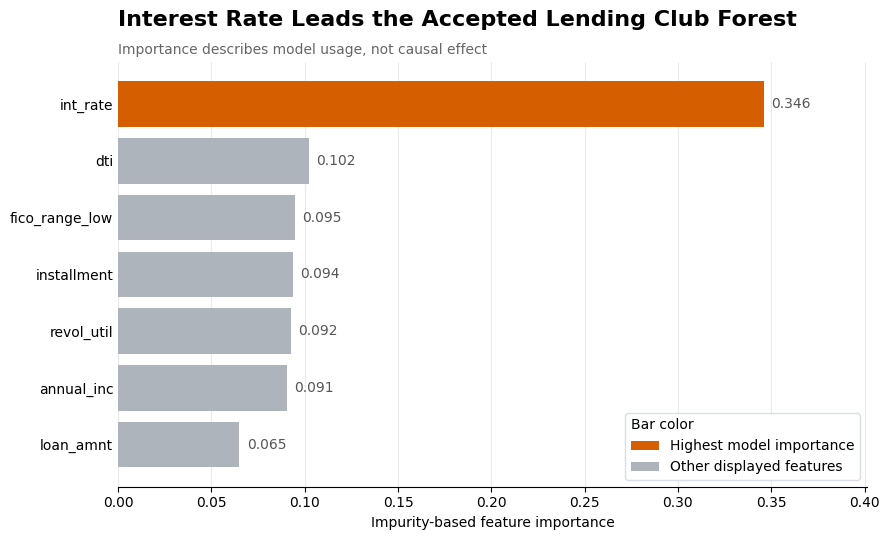

In [15]:
from matplotlib.patches import Patch

lending_importance_w10 = lending_w10_result[1].sort_values().tail(7)
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#AEB4BC"] * (len(lending_importance_w10) - 1) + ["#D55E00"]
bars = ax.barh(
    lending_importance_w10.index,
    lending_importance_w10.values,
    color=colors
)
for bar, value in zip(bars, lending_importance_w10.values):
    ax.text(value + .004, bar.get_y() + bar.get_height()/2,
            f"{value:.3f}", va="center", color="#555555")
ax.set_xlim(0, lending_importance_w10.max() * 1.16)
ax.set_title("Interest Rate Leads the Accepted Lending Club Forest",
             loc="left", fontsize=16, weight="bold", pad=26)
ax.text(0, 1.02, "Importance describes model usage, not causal effect",
        transform=ax.transAxes, color="#666666", fontsize=10)
ax.set_xlabel("Impurity-based feature importance")
legend_handles = [
    Patch(facecolor="#D55E00", label="Highest model importance"),
    Patch(facecolor="#AEB4BC", label="Other displayed features")
]
legend = ax.legend(handles=legend_handles, title="Bar color",
                   loc="lower right", frameon=True, facecolor="white",
                   edgecolor="#D9DEE5", framealpha=1)
legend._legend_box.align = "left"
ax.grid(axis="x", color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

**Interpretation.** Both forests rank adverse outcomes better than chance, but they rely on different schemas and should not be compared feature-for-feature. Cross-validation estimates stability within each training population; the held-out score checks generalization once. The mortgage model uses complete cases to avoid missing underwriting fields acting as outcome proxies. The Lending Club model uses an evenly spaced sample of accepted loans. Week 11 performs the more extensive hyperparameter tuning and threshold-oriented evaluation.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter six (p. 151-163) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

## Plot 1 - Mortgage Loan Default

Chapter 6 emphasizes intentional design choices in model visuals. This mortgage figure follows the horizontal stacked-bar approach: categories are ordered, all bars use the same 100% denominator, labels are direct, and adverse outcomes receive the only strong color.

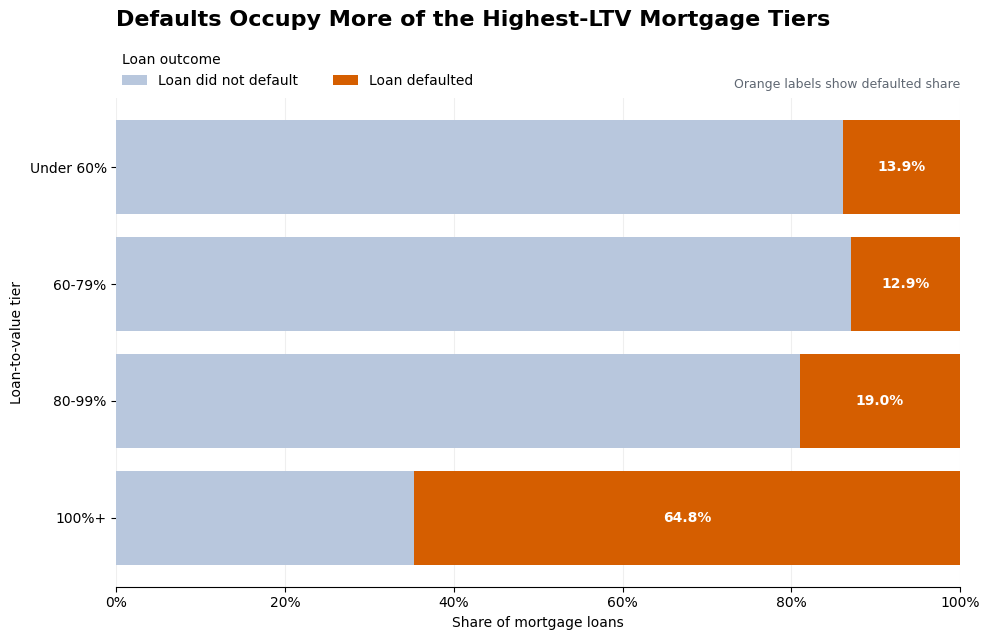

In [16]:
# Prepare the mortgage outcome composition.
import matplotlib.ticker as mticker

mortgage = pd.read_csv("DATA/Loan_Default.csv", usecols=["LTV", "Status"])
mortgage = mortgage.loc[mortgage["LTV"].between(0, 150)].copy()
mortgage["LTV tier"] = pd.cut(
    mortgage["LTV"], [0, 60, 80, 100, 151], right=False,
    labels=["Under 60%", "60-79%", "80-99%", "100%+"]
)
mortgage_mix = (
    mortgage.groupby("LTV tier", observed=True)["Status"]
    .agg(default_rate="mean", loans="size").reset_index()
)
mortgage_mix["not_defaulted"] = 1 - mortgage_mix["default_rate"]

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(mortgage_mix))
ax.barh(y, mortgage_mix["not_defaulted"], color="#B8C7DD",
        label="Loan did not default")
ax.barh(y, mortgage_mix["default_rate"], left=mortgage_mix["not_defaulted"],
        color="#D55E00", label="Loan defaulted")
for yi, performing, adverse in zip(
    y, mortgage_mix["not_defaulted"], mortgage_mix["default_rate"]
):
    ax.text(performing + adverse/2, yi, f"{adverse:.1%}",
            ha="center", va="center", color="white", weight="bold")

ax.set_yticks(y, mortgage_mix["LTV tier"].astype(str))
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Share of mortgage loans")
ax.set_ylabel("Loan-to-value tier")
ax.set_title("Defaults Occupy More of the Highest-LTV Mortgage Tiers",
             loc="left", fontsize=16, weight="bold", pad=52)
legend = ax.legend(title="Loan outcome", loc="lower left",
                   bbox_to_anchor=(0, 1.01), ncol=2, frameon=False,
                   borderaxespad=0, handlelength=1.8, columnspacing=2.5)
legend._legend_box.align = "left"
ax.text(1, 1.015, "Orange labels show defaulted share",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color="#5F6772")
ax.grid(axis="x", alpha=.2)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Mortgage design interpretation.** The common baseline makes outcome shares easy to compare. The plain-language legend defines both colors, while the labels inside the orange segments give the exact default share. Ordering the LTV tiers creates a deliberate low-to-high risk reading path.

## Plot 2 - Accepted Lending Club Loans

The Lending Club figure uses the same Chapter 6 design principles in a standalone plot. It does not share an axis or legend with the mortgage data, so its distinct bad-loan definition remains clear.

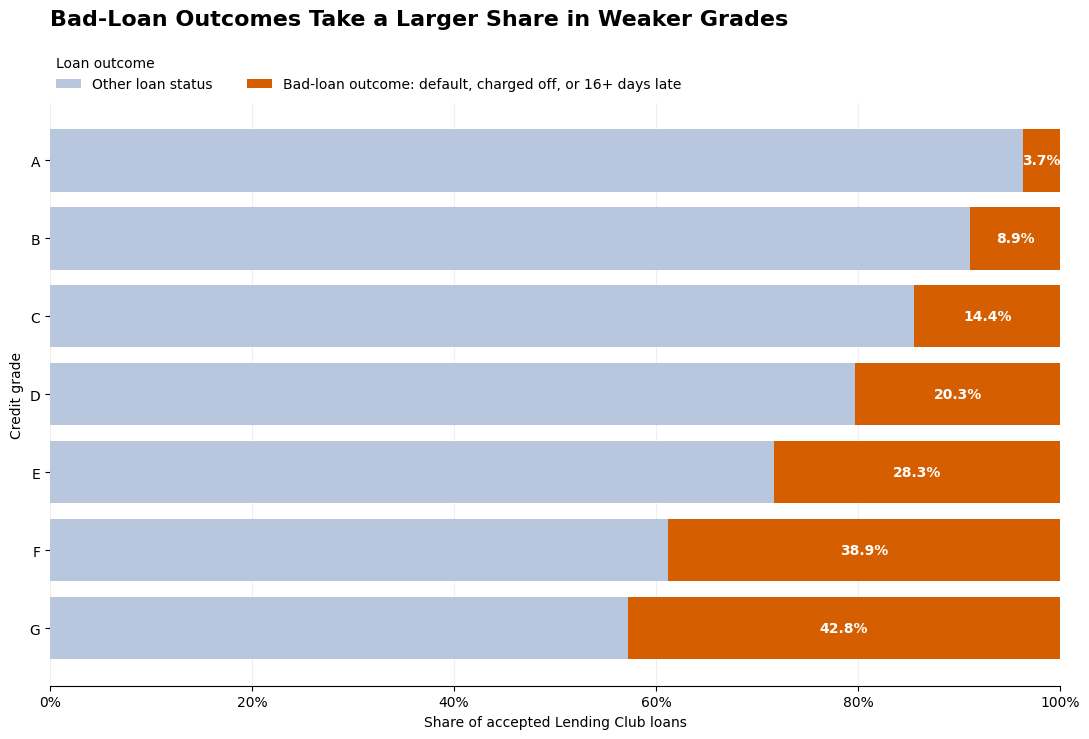

In [17]:
# Prepare accepted Lending Club outcome composition.
from pathlib import Path

accepted_path = Path(
    "DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/"
    "accepted_2007_to_2018Q4.csv"
)
total_rows = sum(1 for _ in open(accepted_path, encoding="utf-8")) - 1
every = max(total_rows // 60000, 1)
accepted = pd.read_csv(
    accepted_path, usecols=["grade", "loan_status"],
    skiprows=lambda row: row > 0 and row % every != 0, low_memory=False
)
bad_statuses = {
    "Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
    "Does not meet the credit policy. Status:Charged Off"
}
accepted["bad_loan"] = accepted["loan_status"].isin(bad_statuses).astype(int)
lending_mix = (
    accepted.dropna(subset=["grade"]).groupby("grade")["bad_loan"]
    .agg(bad_loan_rate="mean", loans="size").reset_index().sort_values("grade")
)
lending_mix["performing"] = 1 - lending_mix["bad_loan_rate"]

fig, ax = plt.subplots(figsize=(11, 7.5))
y = np.arange(len(lending_mix))
ax.barh(y, lending_mix["performing"], color="#B8C7DD",
        label="Other loan status")
ax.barh(y, lending_mix["bad_loan_rate"], left=lending_mix["performing"],
        color="#D55E00",
        label="Bad-loan outcome: default, charged off, or 16+ days late")
for yi, performing, adverse in zip(
    y, lending_mix["performing"], lending_mix["bad_loan_rate"]
):
    ax.text(performing + adverse/2, yi, f"{adverse:.1%}",
            ha="center", va="center", color="white", weight="bold")

ax.set_yticks(y, lending_mix["grade"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Share of accepted Lending Club loans")
ax.set_ylabel("Credit grade")
ax.set_title("Bad-Loan Outcomes Take a Larger Share in Weaker Grades",
             loc="left", fontsize=16, weight="bold", pad=56)
legend = ax.legend(title="Loan outcome", loc="lower left",
                   bbox_to_anchor=(0, 1.01), ncol=2, frameon=False,
                   borderaxespad=0, handlelength=1.8, columnspacing=2.5)
legend._legend_box.align = "left"
ax.grid(axis="x", alpha=.2)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Lending Club design interpretation.** The A-to-G ordering and common 100% baseline make deterioration visible without combining portfolios. The legend names the muted-blue category and defines the orange bad-loan outcome in plain language; the orange segment labels provide the exact bad-loan share.